Kinematic Analysis

Metric                                   | j1_v     | j2_v     | j3_v     | j4_v     | j5_v     | j6_v     | AVG          | AVG_P10      | AVG_P90     
-------------------------------------------------------------------------------------------------------------------------------------------------------
N_Segments_X_cycle                       | 6        | 11       | 8        | 8        | 11       | 8        | 8,82         | 7,00         | 11,00       
Mean_segment_duration (in ts)            | 837,96   | 497,92   | 574,35   | 290,29   | 397,88   | 396,83   | 499,21       | 343,56       | 706,15      
Mean_duration_of_single_Acc|Dec (in ts)  | 234,11   | 135,19   | 149,47   | 100,95   | 115,89   | 129,20   | 144,14       | 108,42       | 191,79      
Mean_constant_vel (ts)                   | 369,73   | 227,54   | 275,41   | 88,38    | 166,10   | 138,43   | 210,93       | 113,40       | 322,57      



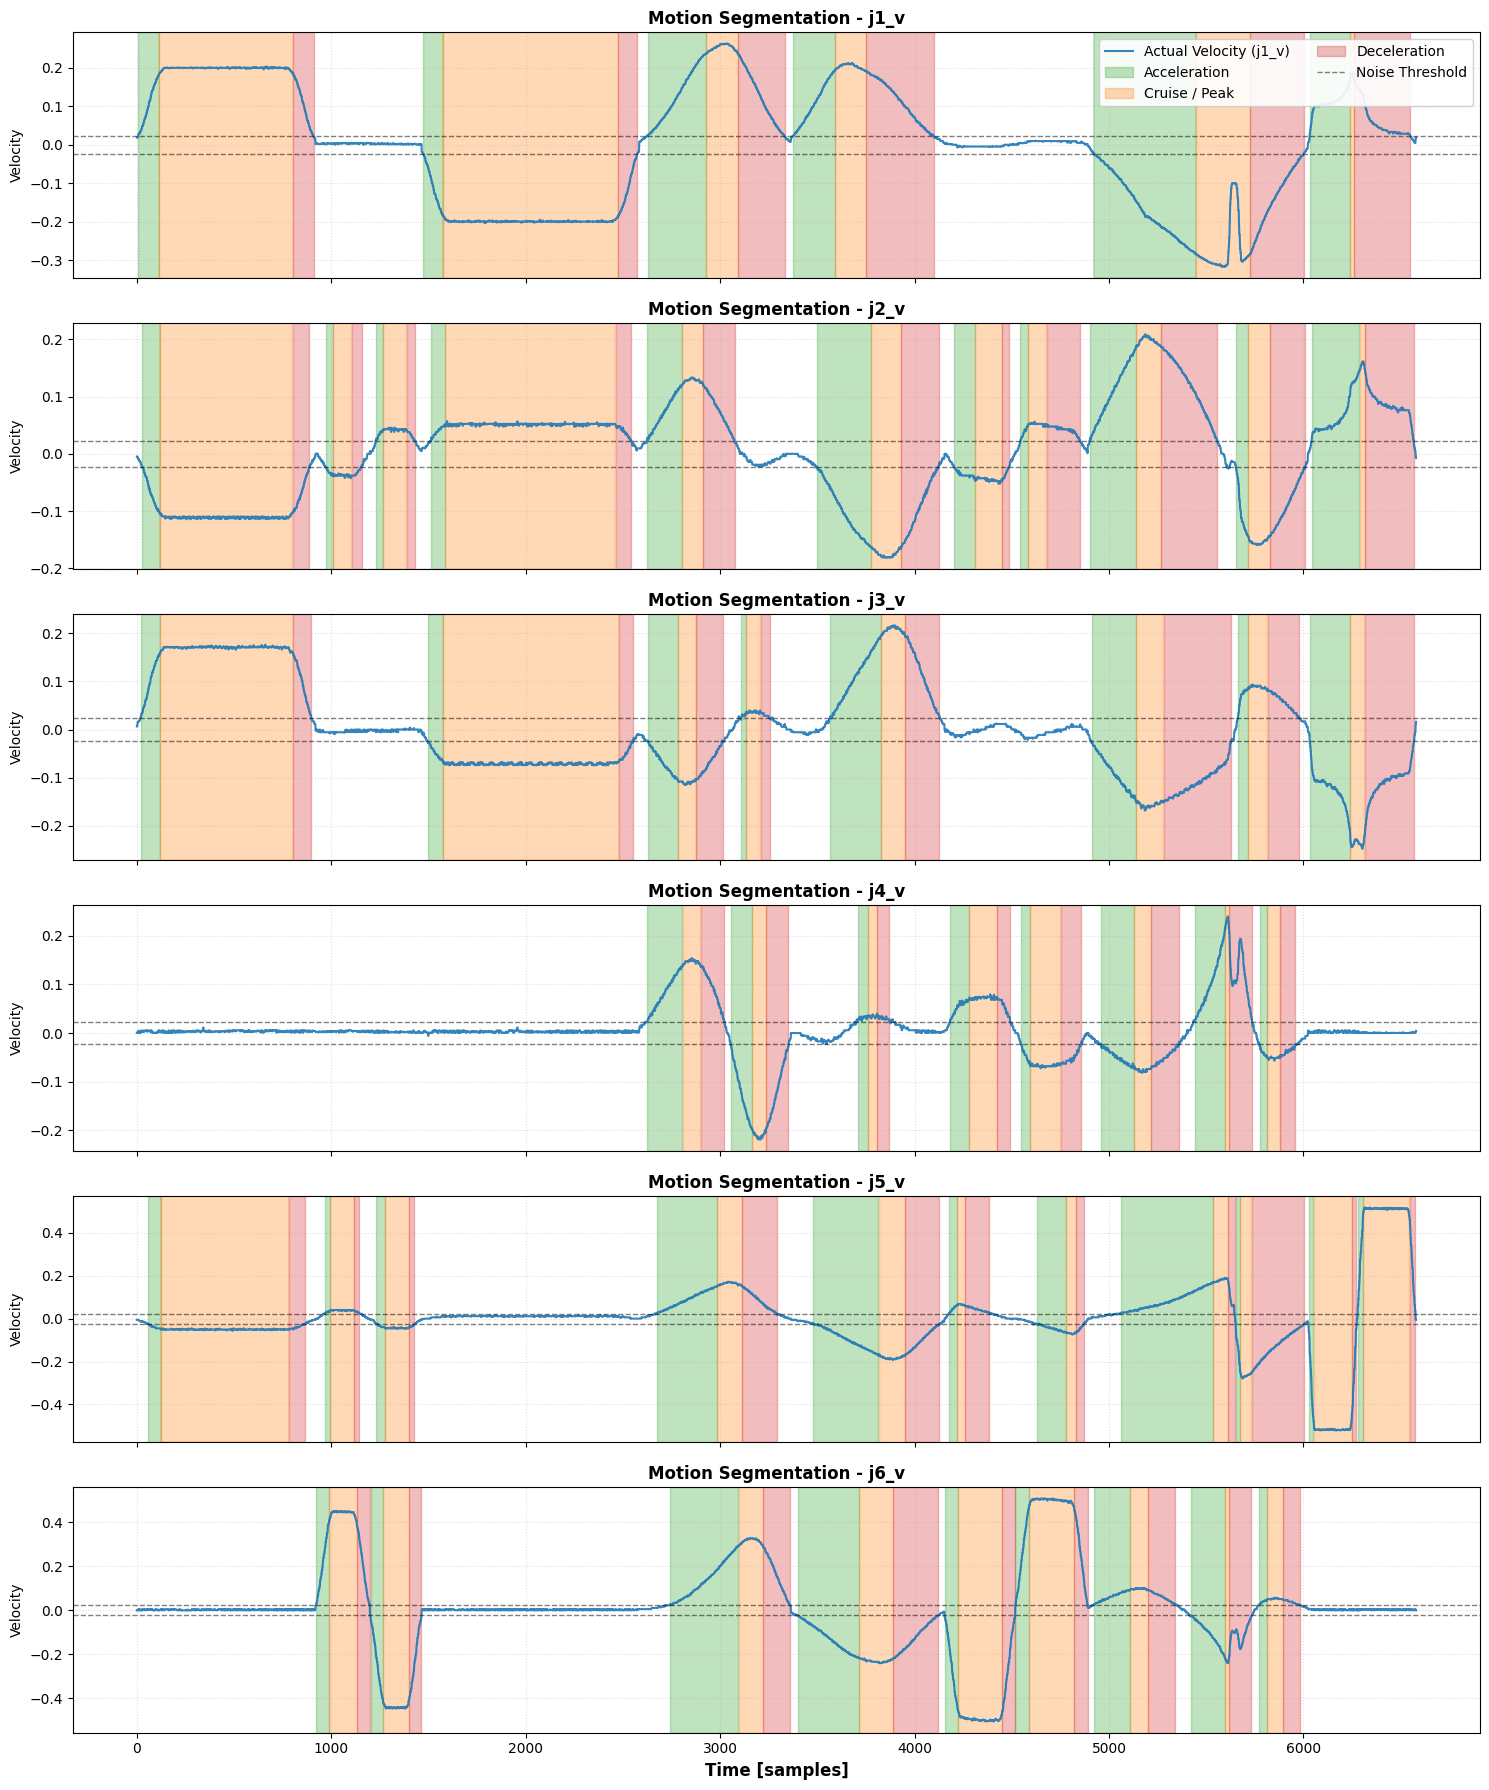

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
#df = pd.read_csv("C:\\Users\\Carlo\\time-series-autoencoder\\examples\\reconstruction\\QUERY_CSV_TOTALE_EXCEL_FATTO_SANE_ORIGINALE.csv", sep=";", decimal=",")

df = pd.read_csv("C:\\Users\\Carlo\\time-series-autoencoder\\examples\\reconstruction\\NUOVI DATI RACCOLTI\\QUERY_CSV_SANE_EXCEL.csv", sep=";", decimal=",")

# Define the target joint velocity columns
joints = ['j1_v', 'j2_v', 'j3_v', 'j4_v', 'j5_v', 'j6_v']

# 2. Define the noise threshold to filter out idle state noise
noise_threshold = 0.023 

# Limit the plot to a specific number of samples for better readability
sample_limit = min(6580, len(df)) 

# Initialize the figure with 6 stacked subplots, sharing the X-axis
fig, axs = plt.subplots(6, 1, figsize=(15, 18), sharex=True)

# --- NUOVO: Liste per memorizzare le statistiche ---
stats_segments = []
stats_duration = []
stats_acc_dec = []
valid_joints = []

# Iterate over each joint
for i, joint in enumerate(joints):
    if joint not in df.columns:
        print(f"Warning: Column {joint} not found in the DataFrame.")
        continue
        
    velocity = df[joint].values
    valid_joints.append(joint) # Salviamo il nome del giunto per le colonne della tabella
    
    # 3. Boolean mask: True if the joint is moving, False if idle
    is_moving = np.abs(velocity) > noise_threshold
    
    # 4. Compute the lengths of the motion segments
    state_changes = np.diff(is_moving.astype(int))
    starts = np.where(state_changes == 1)[0] + 1
    ends = np.where(state_changes == -1)[0] + 1
    
    if len(is_moving) > 0:
        if is_moving[0]:
            starts = np.insert(starts, 0, 0)
        if is_moving[-1]:
            ends = np.append(ends, len(is_moving))
            
    # --- MASCHERE PER IL PLOT ---
    is_accelerating = np.zeros(len(velocity), dtype=bool)
    is_cruising = np.zeros(len(velocity), dtype=bool)
    is_decelerating = np.zeros(len(velocity), dtype=bool)
    
    valid_segment_lengths = []
    accel_lengths = []
    decel_lengths = []
    
    for s, e in zip(starts, ends):
        segment_len = e - s
        if segment_len > 50:  # Filtro per segmenti validi
            valid_segment_lengths.append(segment_len)
            
            segment_speed = np.abs(velocity[s:e])
            max_speed = np.max(segment_speed)
            peak_threshold = max_speed * 0.90 
            
            peak_indices = np.where(segment_speed >= peak_threshold)[0]
            
            if len(peak_indices) > 0:
                # Indici globali rispetto all'intero array 'velocity'
                start_cruise = s + peak_indices[0]
                end_cruise = s + peak_indices[-1] + 1
                
                # Popoliamo le maschere per il plot
                is_accelerating[s:start_cruise] = True
                is_cruising[start_cruise:end_cruise] = True
                is_decelerating[end_cruise:e] = True
                
                # Salvataggio delle lunghezze per le statistiche
                accel_lengths.append(start_cruise - s)
                decel_lengths.append(e - end_cruise)
    
    # --- NUOVO: Salvataggio delle metriche invece di stamparle subito ---
    if len(valid_segment_lengths) > 0:
        stats_segments.append(len(valid_segment_lengths))
        stats_duration.append(np.mean(valid_segment_lengths))
        
        if len(accel_lengths) > 0:
            mean_between = (np.mean(accel_lengths) + np.mean(decel_lengths)) / 2
            stats_acc_dec.append(mean_between)
        else:
            stats_acc_dec.append(np.nan)
    else:
        stats_segments.append(0)
        stats_duration.append(np.nan)
        stats_acc_dec.append(np.nan)

    # --- 5. GRAPHICAL VISUALIZATION ---
    ax = axs[i]
    
    # Plot the actual velocity signal
    ax.plot(
        velocity[:sample_limit], 
        color='tab:blue', 
        linewidth=1.5,
        alpha=0.9, 
        label=f'Actual Velocity ({joint})'
    )
    
    # Evidenziazione delle tre fasi con colori differenti
    x_vals = np.arange(sample_limit)
    
    ax.fill_between(
        x_vals, 0, 1, 
        where=is_accelerating[:sample_limit], 
        color='tab:green', alpha=0.3, transform=ax.get_xaxis_transform(), label='Acceleration'
    )
    ax.fill_between(
        x_vals, 0, 1, 
        where=is_cruising[:sample_limit], 
        color='tab:orange', alpha=0.3, transform=ax.get_xaxis_transform(), label='Cruise / Peak'
    )
    ax.fill_between(
        x_vals, 0, 1, 
        where=is_decelerating[:sample_limit], 
        color='tab:red', alpha=0.3, transform=ax.get_xaxis_transform(), label='Deceleration'
    )
    
    # Draw threshold limits
    ax.axhline(y=noise_threshold, color='black', linestyle='--', alpha=0.5, linewidth=1, label='Noise Threshold')
    ax.axhline(y=-noise_threshold, color='black', linestyle='--', alpha=0.5, linewidth=1)
    
    # Subplot formatting
    ax.set_title(f"Motion Segmentation - {joint}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Velocity", fontsize=10)
    ax.grid(True, alpha=0.4, linestyle=':')
    
    # Display the legend only on the first subplot to avoid clutter
    if i == 0:
        ax.legend(loc='upper right', framealpha=0.9, ncol=2)

# Final figure adjustments
axs[-1].set_xlabel("Time [samples]", fontsize=12, fontweight='bold')
plt.tight_layout()

# --- NUOVO: Stampa Tabellare Finale ---
print("Kinematic Analysis")

# Definiamo le larghezze delle colonne in variabili per garantire l'allineamento perfetto
w_metric = 40
w_joint = 8
w_stat = 12  # Aumentato a 12 per far stare comodamente "AVG_Min 25%" (11 caratteri)

# Intestazione della tabella
header = f"{'Metric':<{w_metric}} | " + " | ".join([f"{j:<{w_joint}}" for j in valid_joints]) + f" | {'AVG':<{w_stat}} | {'AVG_P10':<{w_stat}} | {'AVG_P90':<{w_stat}}"

# Calcoliamo dinamicamente la lunghezza della riga divisoria in base all'header
line_length = len(header)

print("\n" + "=" * line_length)
print(header)
print("-" * line_length)

# Funzione helper per formattare uniformemente i valori (virgole al posto dei punti e gestione NaN)
def format_val(val):
    if pd.isna(val):
        return "N/A"
    return f"{val:.2f}".replace('.', ',')

#1. Riga Segments
stats_segments_div8 =[s / 25 for s in stats_segments]

avg_segments = np.mean(stats_segments_div8)
p25_seg = np.nanpercentile(stats_segments_div8, 10)
p75_seg = np.nanpercentile(stats_segments_div8, 90)

# Disattivate...
#avg_segments = np.mean(stats_segments)
#p25_seg = np.nanpercentile(stats_segments, 10)
#p75_seg = np.nanpercentile(stats_segments, 90)

row_seg = f"{'N_Segments_X_cycle':<{w_metric}} | " + " | ".join([f"{int(s):<{w_joint}}" for s in stats_segments_div8]) + f" | {format_val(avg_segments):<{w_stat}} | {format_val(p25_seg):<{w_stat}} | {format_val(p75_seg):<{w_stat}}"
print(row_seg)


# 2. Riga Mean Duration
avg_duration = np.nanmean(stats_duration)
p25_dur = np.nanpercentile(stats_duration, 10)
p75_dur = np.nanpercentile(stats_duration, 90)
row_dur = f"{'Mean_segment_duration (in ts)':<{w_metric}} | " + " | ".join([f"{format_val(d):<{w_joint}}" for d in stats_duration]) + f" | {format_val(avg_duration):<{w_stat}} | {format_val(p25_dur):<{w_stat}} | {format_val(p75_dur):<{w_stat}}"
print(row_dur)

# 3. Riga Mean Acc/Dec
avg_acc_dec = np.nanmean(stats_acc_dec)
p25_acc = np.nanpercentile(stats_acc_dec, 10)
p75_acc = np.nanpercentile(stats_acc_dec, 90)
row_acc = f"{'Mean_duration_of_single_Acc|Dec (in ts)':<{w_metric}} | " + " | ".join([f"{format_val(a):<{w_joint}}" for a in stats_acc_dec]) + f" | {format_val(avg_acc_dec):<{w_stat}} | {format_val(p25_acc):<{w_stat}} | {format_val(p75_acc):<{w_stat}}"
print(row_acc)

stats_cruise_calc = [
    (d - (a * 2)) if not (pd.isna(d) or pd.isna(a)) else np.nan 
    for d, a in zip(stats_duration, stats_acc_dec)
]

avg_cruise = np.nanmean(stats_cruise_calc)
p25_cruise = np.nanpercentile(stats_cruise_calc, 10)
p75_cruise = np.nanpercentile(stats_cruise_calc, 90)

row_cruise = f"{'Mean_constant_vel (ts)':<{w_metric}} | " + \
             " | ".join([f"{format_val(c):<{w_joint}}" for c in stats_cruise_calc]) + \
             f" | {format_val(avg_cruise):<{w_stat}} | {format_val(p25_cruise):<{w_stat}} | {format_val(p75_cruise):<{w_stat}}"

print(row_cruise)


print("=" * line_length + "\n")

# Display the plot
plt.show()

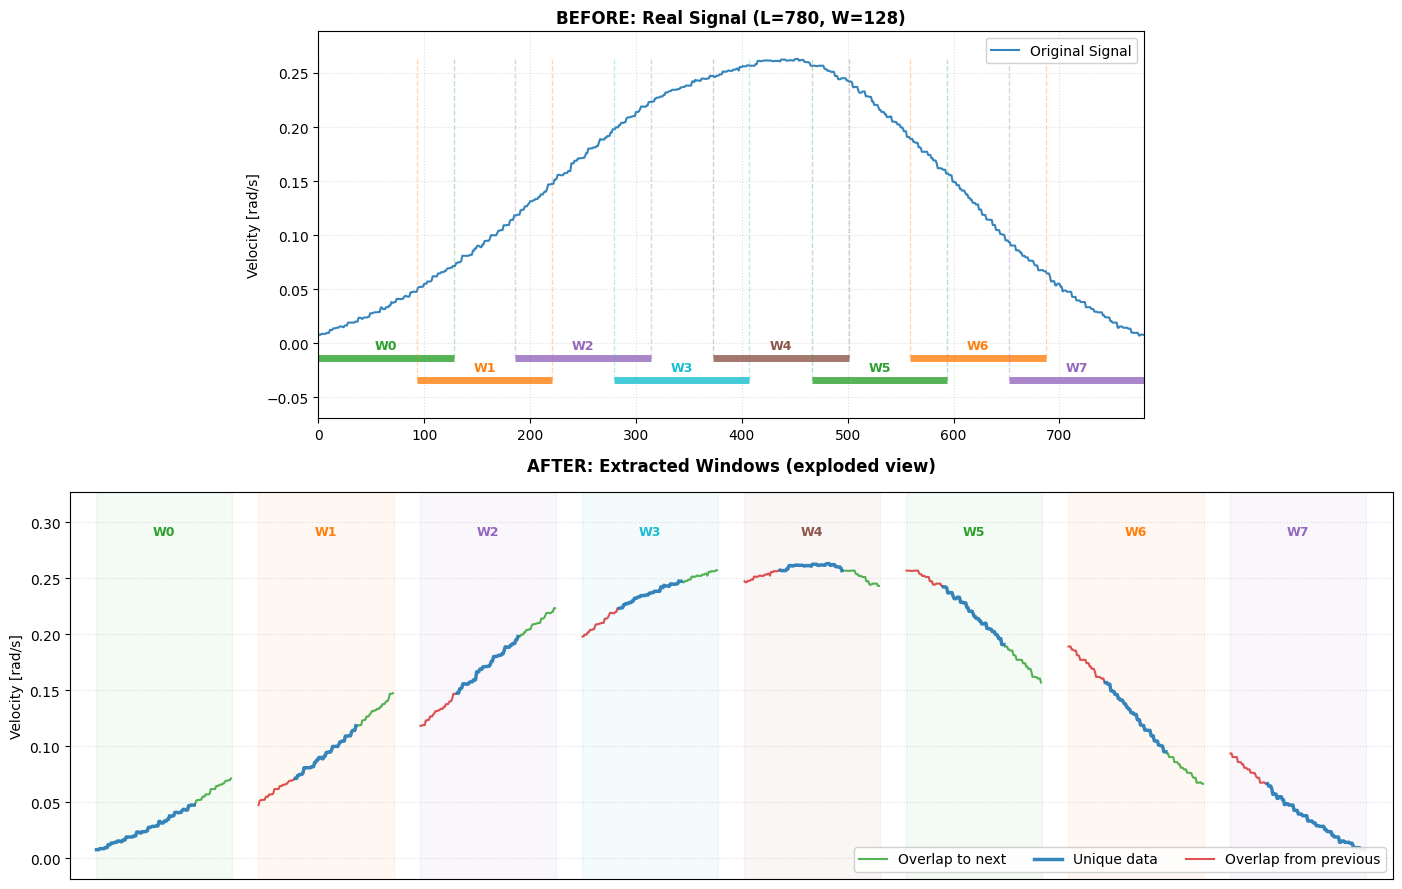

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_dynamic_windows(L, W, O_min):
    if L <= W: return [0]
    S_max = W - O_min
    N = int(np.ceil((L - W) / S_max)) + 1
    S_eff = (L - W) / (N - 1) if N > 1 else 0
    return [int(round(i * S_eff)) for i in range(N)]

# --- PREPARAZIONE DATI DA CSV ---
df = pd.read_csv("C:\\Users\\Carlo\\time-series-autoencoder\\examples\\reconstruction\\NUOVI DATI RACCOLTI\\QUERY_CSV_SANE_EXCEL.csv", sep=";", decimal=",")

signal = df[df['trajectory_id'] == 5]['j1_v'].values
signal = signal[~np.isnan(signal)]

L = len(signal)
W = 128        
O_min = 20     
starts = get_dynamic_windows(L, W, O_min)

SAMPLES_PER_INCH = 100  
gap = 25               

max_x_needed = len(starts) * (W + gap)
fig_width = (max_x_needed / SAMPLES_PER_INCH) + 2

colors = ['tab:green', 'tab:orange', 'tab:purple', 'tab:cyan', 'tab:brown']

# --- CREAZIONE PLOT ---
fig, axs = plt.subplots(2, 1, figsize=(fig_width, 9))

# --- PRIMA: Segnale Originale ---
ax0 = axs[0]
ax0.plot(signal, color='tab:blue', linewidth=1.5, alpha=0.9, label='Original Signal')

y_min, y_max = np.min(signal), np.max(signal)
y_range = y_max - y_min
if y_range == 0: y_range = 1  

ax0.set_ylim(y_min - 0.3 * y_range, y_max + 0.1 * y_range)

base_y = y_min - 0.08 * y_range
step_y = 0.08 * y_range

for i, start in enumerate(starts):
    end = start + W
    color = colors[i % len(colors)]
    y_pos = base_y - (i % 2) * step_y
    
    ax0.plot([start, end], [y_pos, y_pos], color=color, linewidth=5, alpha=0.8, solid_capstyle='butt')
    ax0.vlines(x=[start, end], ymin=y_pos, ymax=y_max, color=color, linestyle='--', alpha=0.3, linewidth=1)
    ax0.text(start + (W/2), y_pos + (0.02 * y_range), f'W{i}', color=color, fontsize=9, ha='center', va='bottom', fontweight='bold')

ax0.set_title(f"BEFORE: Real Signal (L={L}, W={W})", fontsize=12, fontweight='bold')
ax0.set_ylabel("Velocity [rad/s]", fontsize=10)
ax0.grid(True, alpha=0.4, linestyle=':')
ax0.legend(loc='upper right', framealpha=0.9)
ax0.set_xlim(0, L) 

# --- DOPO: Segnale Esploso in Windows (con evidenziazione simmetrica overlap) ---
ax1 = axs[1]

# Per la legenda: registriamo se abbiamo già aggiunto ciascuna etichetta
labels_added = {"Overlap from previous": False, "Overlap to next": False, "Unique data": False}

for i, start in enumerate(starts):
    win_data = signal[start : start+W]
    x_base = i * (W + gap)
    x_win = np.arange(x_base, x_base + len(win_data))
    color = colors[i % len(colors)]
    
    # Sfondo colorato della finestra
    ax1.axvspan(x_base, x_base + W, color=color, alpha=0.05)
    ax1.text(x_base + (W/2), y_max + y_range * 0.1, f'W{i}', color=color, fontsize=9, ha='center', fontweight='bold')
    
    # Calcola overlap con la precedente (quanti campioni iniziali sono già stati visti)
    if i > 0:
        overlap_from_prev = min((starts[i-1] + W) - start, len(win_data))
        if overlap_from_prev < 0: overlap_from_prev = 0
    else:
        overlap_from_prev = 0
    
    # Calcola overlap con la successiva (quanti campioni finali verranno rivisti)
    if i < len(starts)-1:
        next_start = starts[i+1]
        overlap_to_next = max(0, start + W - next_start)
        if overlap_to_next > len(win_data): overlap_to_next = len(win_data)
    else:
        overlap_to_next = 0
    
    # Segmenti:
    # 1. Inizio (overlap dalla precedente) -> rosso
    if overlap_from_prev > 0:
        label = "Overlap from previous" if not labels_added["Overlap from previous"] else None
        ax1.plot(x_win[:overlap_from_prev], win_data[:overlap_from_prev],
                 color='tab:red', linewidth=1.5, alpha=0.8, label=label)
        labels_added["Overlap from previous"] = True
    
    # 2. Fine (overlap verso la successiva) -> verde
    if overlap_to_next > 0:
        start_final = len(win_data) - overlap_to_next
        label = "Overlap to next" if not labels_added["Overlap to next"] else None
        ax1.plot(x_win[start_final:], win_data[start_final:],
                 color='tab:green', linewidth=1.5, alpha=0.8, label=label)
        labels_added["Overlap to next"] = True
    
    # 3. Parte centrale unica (blu)
    start_central = overlap_from_prev
    end_central = len(win_data) - overlap_to_next
    if start_central < end_central:
        label = "Unique data" if not labels_added["Unique data"] else None
        ax1.plot(x_win[start_central:end_central], win_data[start_central:end_central],
                 color='tab:blue', linewidth=2.5, alpha=0.9, label=label)
        labels_added["Unique data"] = True

ax1.set_title(f"AFTER: Extracted Windows (exploded view)", fontsize=12, fontweight='bold', pad=15)
ax1.set_ylabel("Velocity [rad/s]", fontsize=10)
ax1.grid(True, alpha=0.4, linestyle=':')
ax1.set_xticks([]) 
ax1.legend(loc='lower right', framealpha=0.9, ncol=3)
ax1.set_ylim(y_min - 0.1 * y_range, y_max + 0.25 * y_range)
ax1.set_xlim(-gap, max_x_needed)

# --- MAGIA FINALE: CENTRATURA E MANTENIMENTO SCALA ---
plt.tight_layout()

range_top = L
range_bottom = max_x_needed - (-gap)

pos_top = ax0.get_position()
pos_bottom = ax1.get_position()

width_ratio = range_top / range_bottom
new_width = pos_bottom.width * width_ratio
new_x0 = pos_bottom.x0 + (pos_bottom.width - new_width) / 2

ax0.set_position([new_x0, pos_top.y0, new_width, pos_top.height])

plt.savefig('windowing.png')
plt.show()

In [1]:
import pandas as pd
# 1. Caricamento del file con i parametri corretti per il formato italiano/CSV Excel
#df = pd.read_csv("C:\\Users\\Carlo\\time-series-autoencoder\\examples\\reconstruction\\QUERY_CSV_TOTALE_EXCEL_FATTO_SANE.csv", sep=";", decimal=",")


df = pd.read_csv("C:\\Users\\Carlo\\time-series-autoencoder\\examples\\reconstruction\\NUOVI DATI RACCOLTI\\QUERY_CSV_SANE_EXCEL.csv", sep=";", decimal=",")


# Calculate Delta T and sort descending (from largest delay to smallest)
df = df.sort_values('Timestamp')
df['delta_t'] = df['Timestamp'].diff().dropna()
df_sorted = df.dropna(subset=['delta_t']).sort_values('delta_t', ascending=False)

def calculate_excel_style_freq(data_sorted, keep_percentage):
    # Calculate how many largest delays to exclude
    exclude_n = int(len(data_sorted) * (1 - (keep_percentage / 100)))
    # Keep the remaining smaller delta_t values
    clean_subset = data_sorted['delta_t'].iloc[exclude_n:]
    # Frequency = (Average Delta T)^-1
    return 1 / clean_subset.mean()

# Results
p_list = [99.999, 99.99, 99.9]
results = {p: calculate_excel_style_freq(df_sorted, p) for p in p_list}
# Intestazione con stile
print("\n")
print("AVERAGE FREQUENCY ANALYSIS (Hz)")

print("\nThe percentages below represent the portion of the most stable samples kept for the")
print("calculation, after excluding the largest rows delta_t (delays) in the datastream.")
print("-" * 85)

# Tabella formattata
header = f"{'Metric':<25} | " + " | ".join([f"{p:>10}%" for p in p_list])
print(header)
print("-" * 85)

data_row = f"{'Avg Frequency (Hz)':<25} | " + " | ".join([f"{results[p]:>11.2f}" for p in p_list])
print(data_row)
print("-" * 85 + "\n")



AVERAGE FREQUENCY ANALYSIS (Hz)

The percentages below represent the portion of the most stable samples kept for the
calculation, after excluding the largest rows delta_t (delays) in the datastream.
-------------------------------------------------------------------------------------
Metric                    |     99.999% |      99.99% |       99.9%
-------------------------------------------------------------------------------------
Avg Frequency (Hz)        |       95.97 |       97.34 |      106.54
-------------------------------------------------------------------------------------



FAISS


  JOINT 1
Embedding dimension: 48
Total vectors in the index: 64
Excluded vectors (outliers): []
Vectors used for statistics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]

--- L2 Distance Statistics ---
Absolute minimum (all):          0.000000
Original mean (all):             1.790828
Original median (all):           2.806837
Absolute maximum (all):          4.896436
---------------------------------------
Filtered minimum (without outliers): 0.000000
Filtered mean (without outliers):  1.790828
Filtered median (without outliers):2.806837
Filtered maximum (without outliers):  4.896436

--- Clustering Analysis for Threshold Setting ---

--- THRESHOLD SEARCH RESULT ---
To obtain 7 clusters, the L2 distance must be between:
- MINIMUM:  0.314162
- MAXIMUM: 0.707508


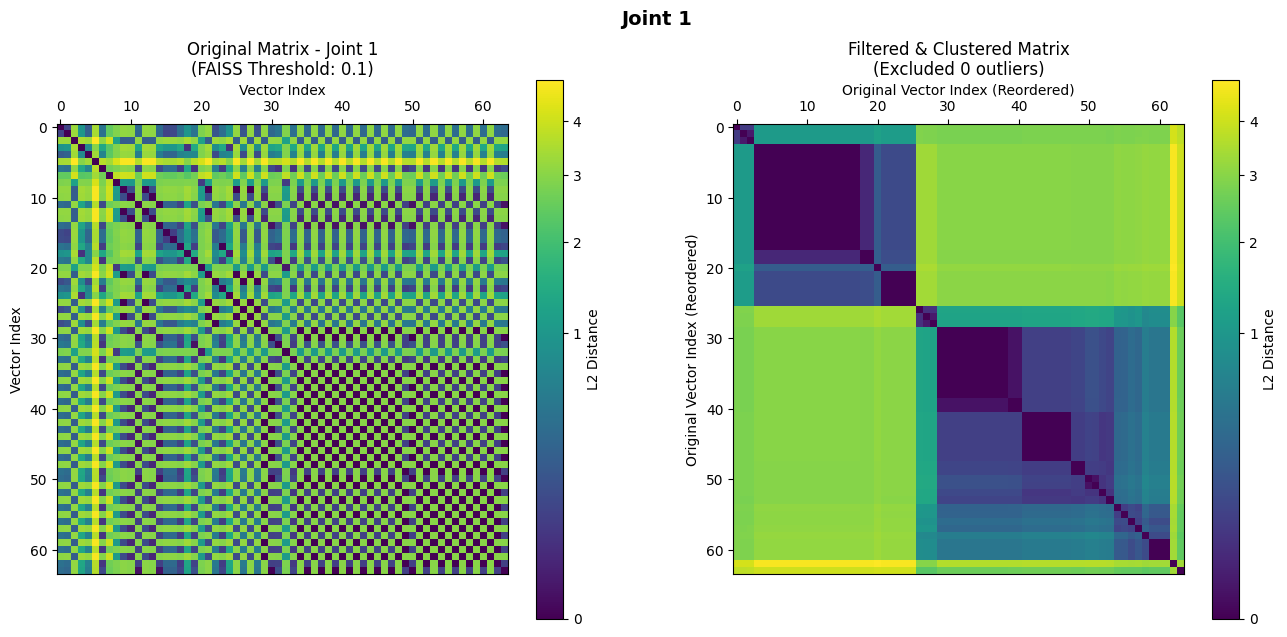

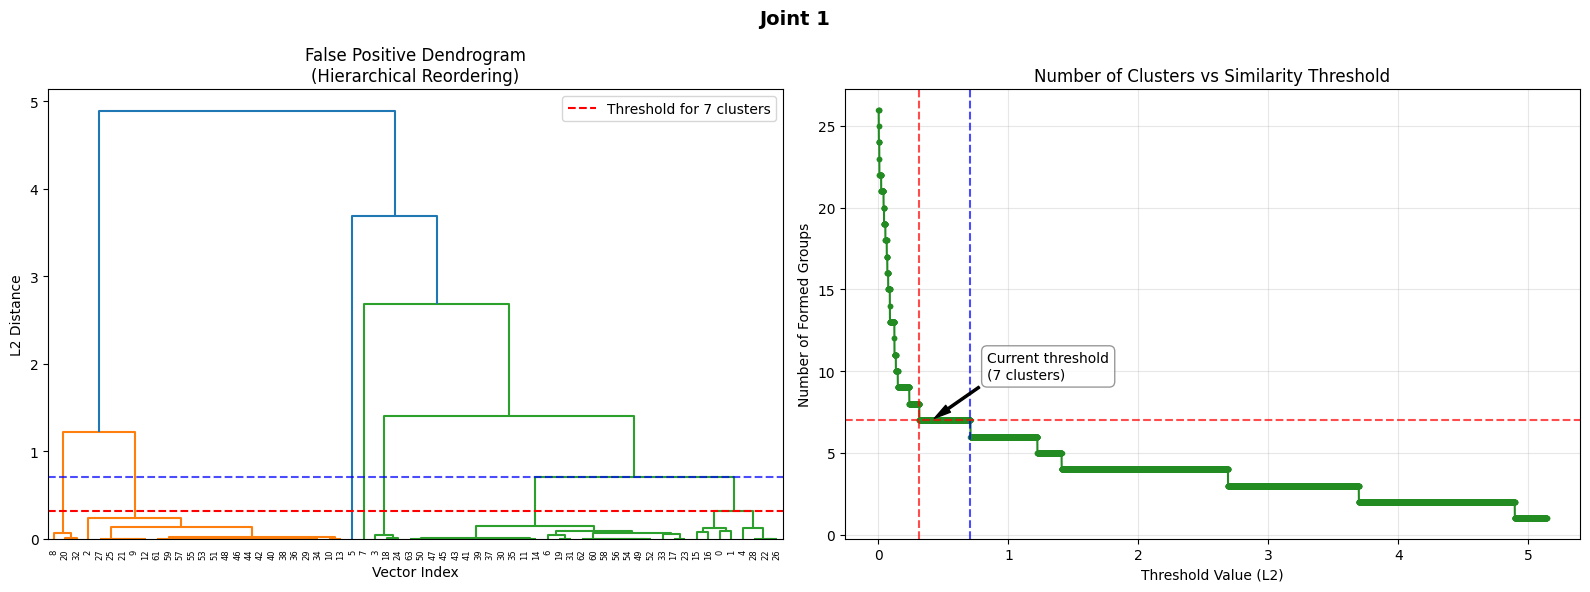


TECHNICAL ADVICE:
- If the number of clusters drops sharply (elbow), that's your ideal threshold.
- With threshold 0.409, your false positives are divided into 7 groups.

  JOINT 2
Embedding dimension: 48
Total vectors in the index: 14
Excluded vectors (outliers): []
Vectors used for statistics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

--- L2 Distance Statistics ---
Absolute minimum (all):          0.000000
Original mean (all):             0.459518
Original median (all):           0.097690
Absolute maximum (all):          2.743658
---------------------------------------
Filtered minimum (without outliers): 0.000000
Filtered mean (without outliers):  0.459518
Filtered median (without outliers):0.097690
Filtered maximum (without outliers):  2.743658

--- Clustering Analysis for Threshold Setting ---

--- THRESHOLD SEARCH RESULT ---
To obtain 2 clusters, the L2 distance must be between:
- MINIMUM:  0.303671
- MAXIMUM: 2.743411


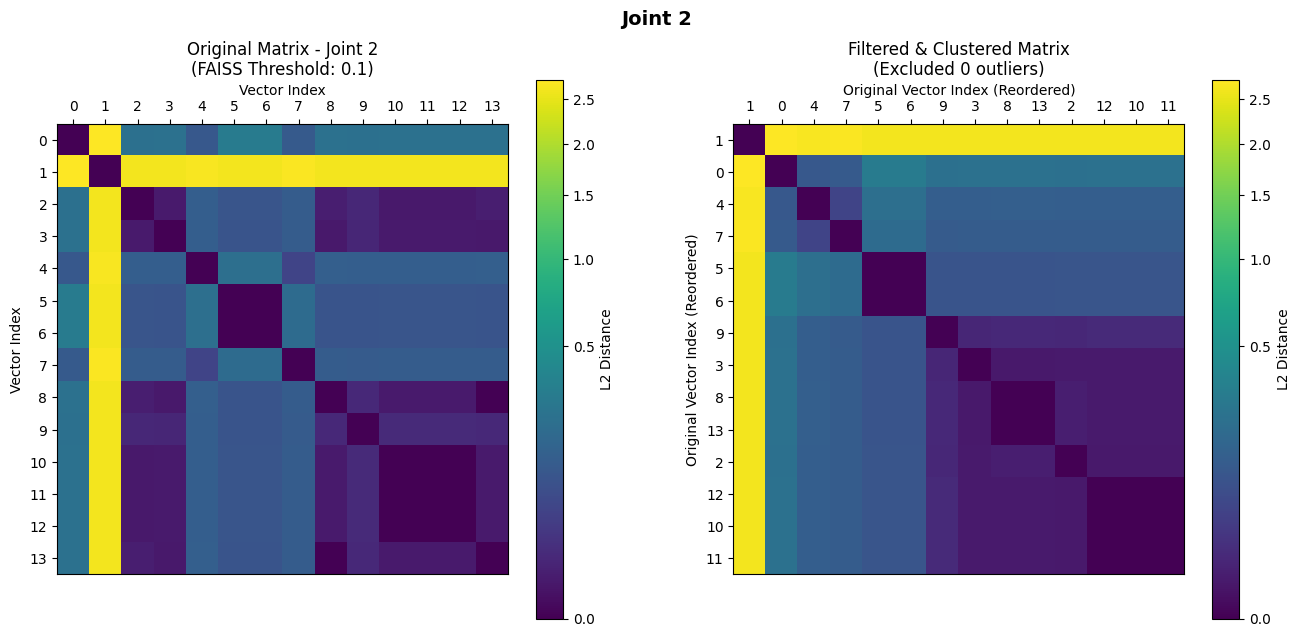

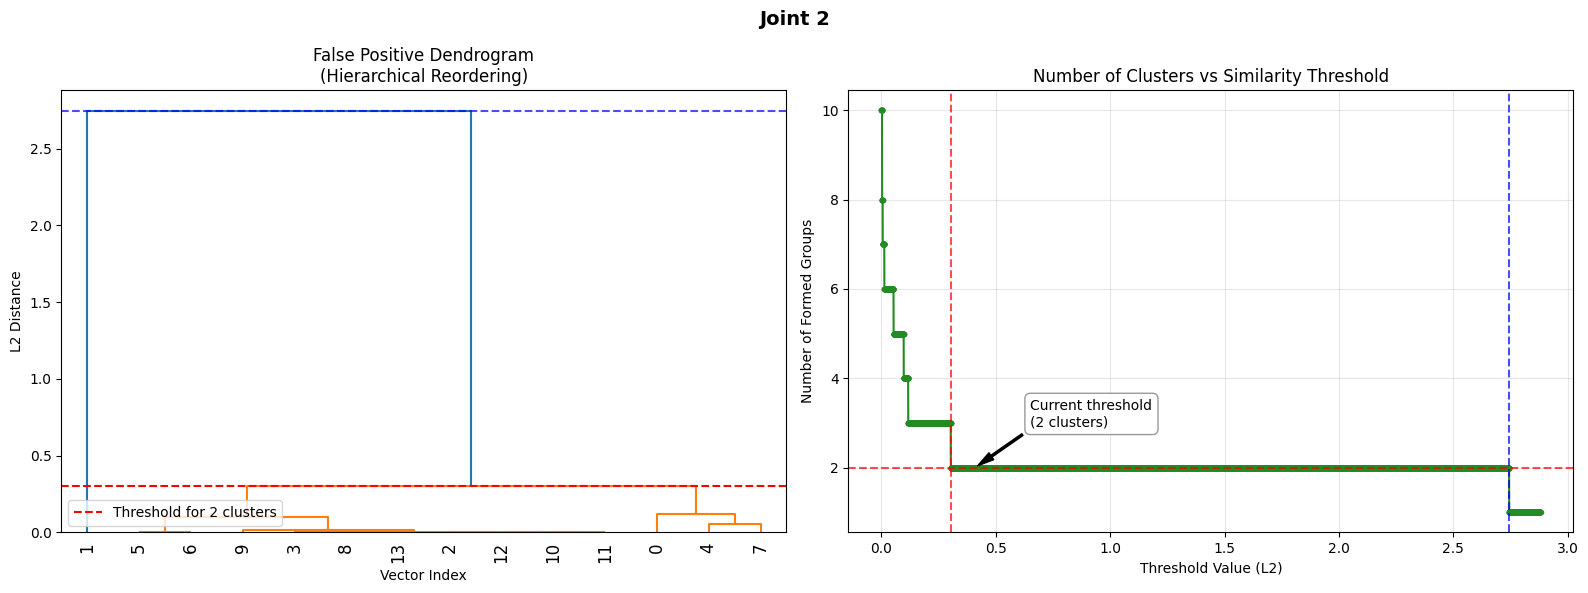


TECHNICAL ADVICE:
- If the number of clusters drops sharply (elbow), that's your ideal threshold.
- With threshold 0.409, your false positives are divided into 2 groups.

  JOINT 3
Embedding dimension: 48
Total vectors in the index: 55
Excluded vectors (outliers): []
Vectors used for statistics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]

--- L2 Distance Statistics ---
Absolute minimum (all):          0.000000
Original mean (all):             1.593920
Original median (all):           2.362481
Absolute maximum (all):          3.108919
---------------------------------------
Filtered minimum (without outliers): 0.000000
Filtered mean (without outliers):  1.593920
Filtered median (without outliers):2.362481
Filtered maximum (without outliers):  3.108919

--- Clustering Analysis for Threshold Setting ---

--- THRESHOLD SEAR

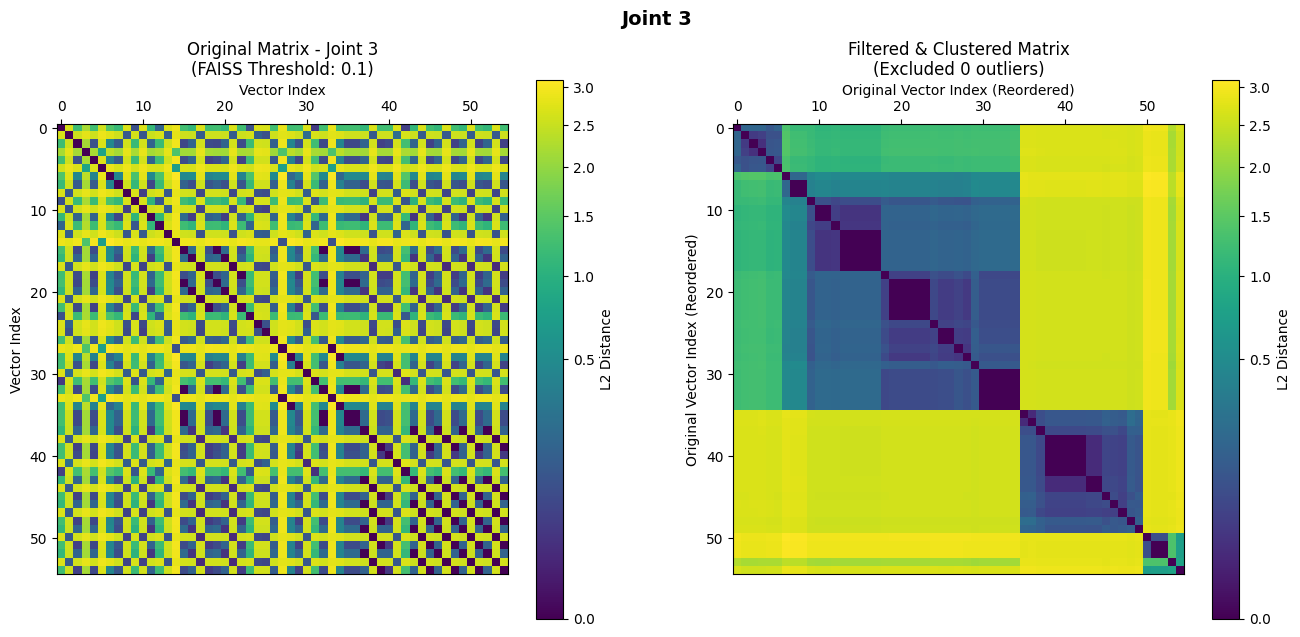

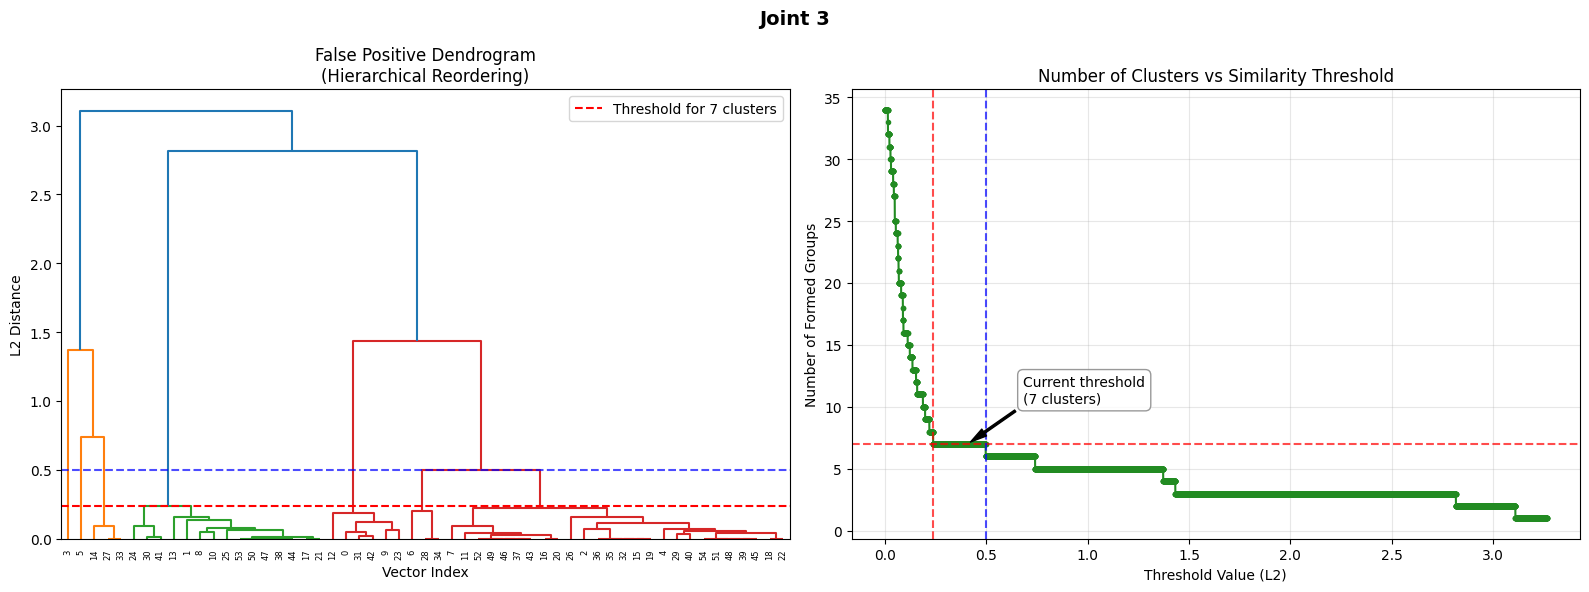


TECHNICAL ADVICE:
- If the number of clusters drops sharply (elbow), that's your ideal threshold.
- With threshold 0.409, your false positives are divided into 7 groups.

  JOINT 4
Embedding dimension: 48
Total vectors in the index: 44
Excluded vectors (outliers): []
Vectors used for statistics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]

--- L2 Distance Statistics ---
Absolute minimum (all):          0.000000
Original mean (all):             0.262696
Original median (all):           0.112747
Absolute maximum (all):          1.561132
---------------------------------------
Filtered minimum (without outliers): 0.000000
Filtered mean (without outliers):  0.262696
Filtered median (without outliers):0.112747
Filtered maximum (without outliers):  1.561132

--- Clustering Analysis for Threshold Setting ---

--- THRESHOLD SEARCH RESULT ---
To obtain 2 clusters, the L2 d

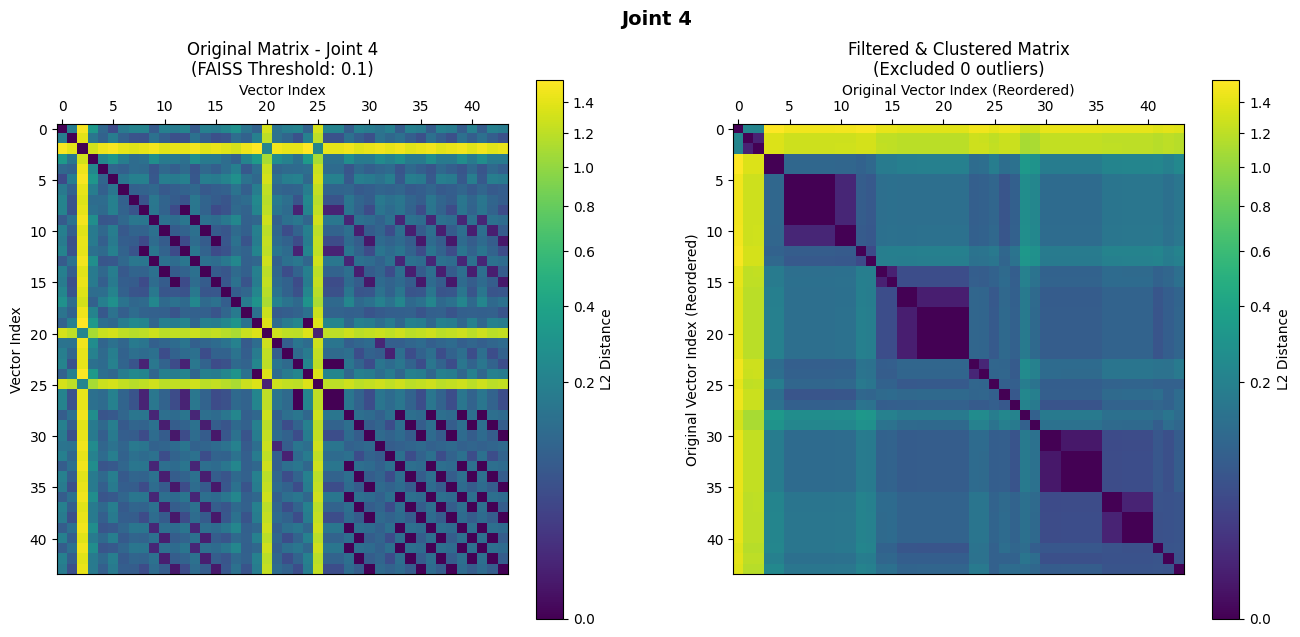

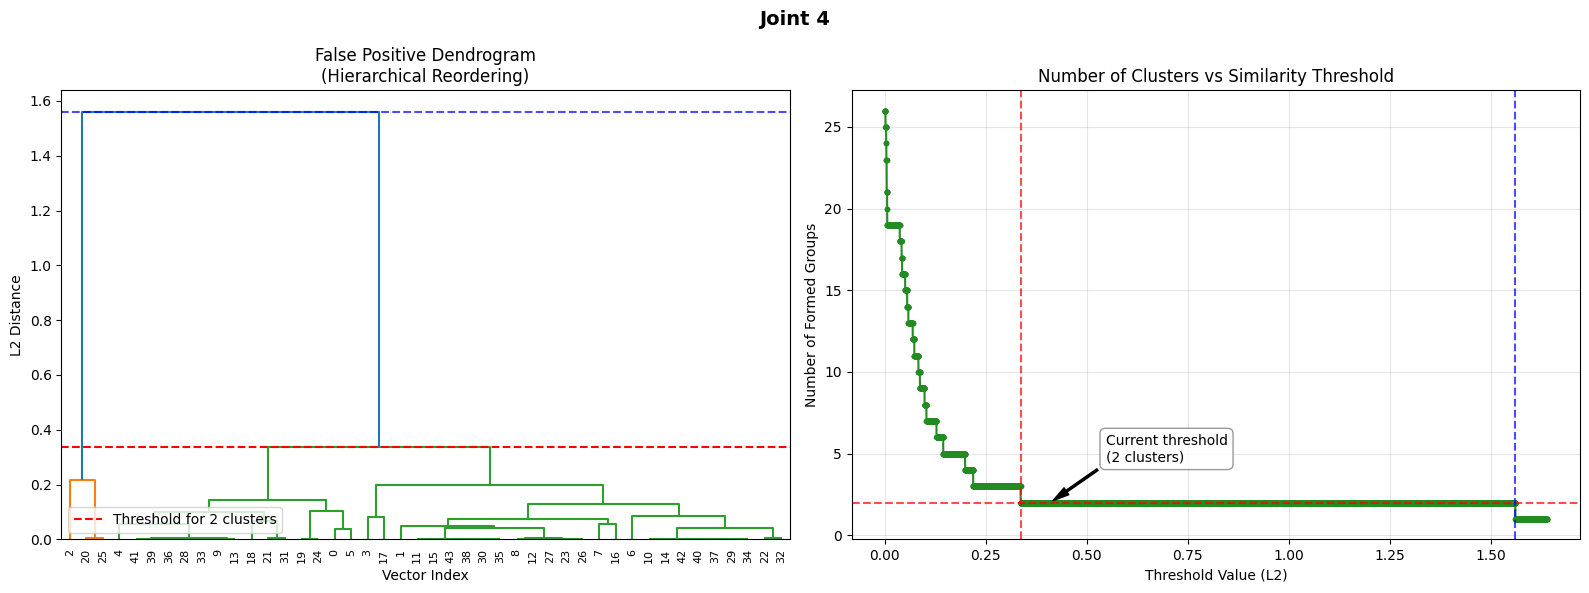


TECHNICAL ADVICE:
- If the number of clusters drops sharply (elbow), that's your ideal threshold.
- With threshold 0.409, your false positives are divided into 2 groups.

  JOINT 5
Embedding dimension: 48
Total vectors in the index: 83
Excluded vectors (outliers): []
Vectors used for statistics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82]

--- L2 Distance Statistics ---
Absolute minimum (all):          0.000000
Original mean (all):             3.231771
Original median (all):           4.290191
Absolute maximum (all):          7.222691
---------------------------------------
Filtered minimum (without outliers): 0.000000
Filtered mean (without outliers):  3.231771
Filtered median (without outliers):4.290191
Filte

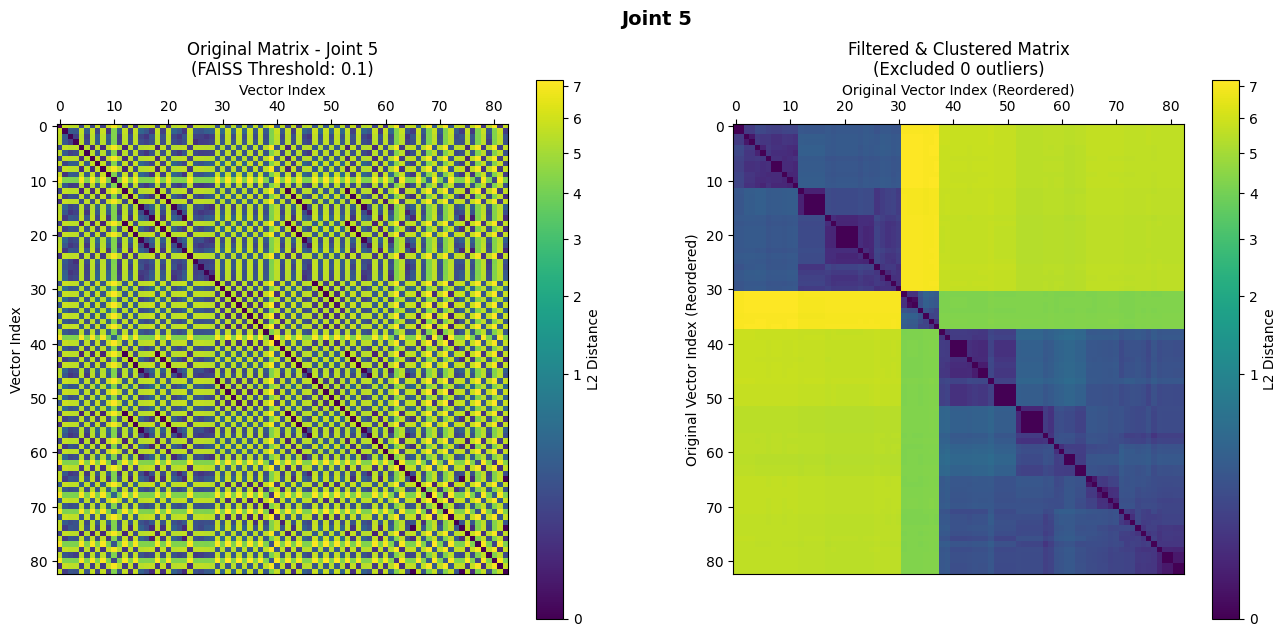

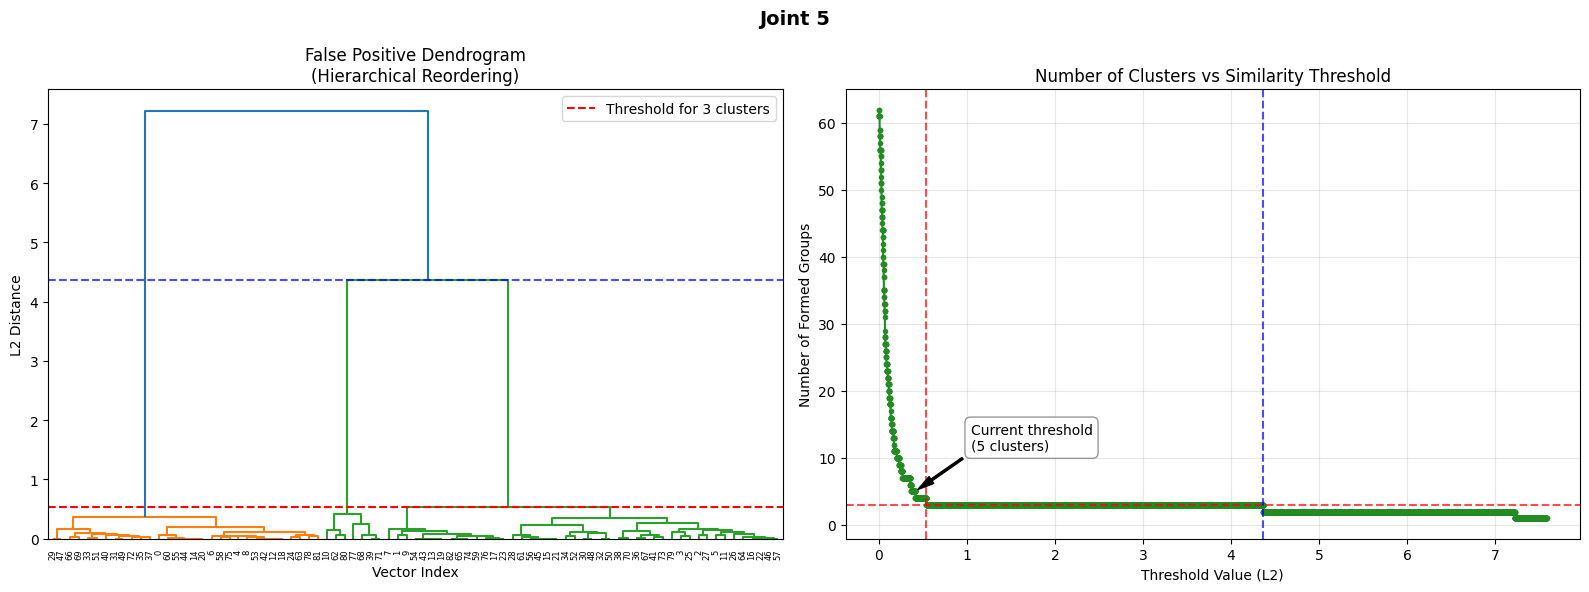


TECHNICAL ADVICE:
- If the number of clusters drops sharply (elbow), that's your ideal threshold.
- With threshold 0.409, your false positives are divided into 5 groups.

  JOINT 6
Embedding dimension: 48
Total vectors in the index: 13
Excluded vectors (outliers): []
Vectors used for statistics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

--- L2 Distance Statistics ---
Absolute minimum (all):          0.004626
Original mean (all):             0.963562
Original median (all):           1.039349
Absolute maximum (all):          2.036289
---------------------------------------
Filtered minimum (without outliers): 0.004626
Filtered mean (without outliers):  0.963562
Filtered median (without outliers):1.039349
Filtered maximum (without outliers):  2.036289

--- Clustering Analysis for Threshold Setting ---

--- THRESHOLD SEARCH RESULT ---
To obtain 5 clusters, the L2 distance must be between:
- MINIMUM:  0.150324
- MAXIMUM: 0.394092


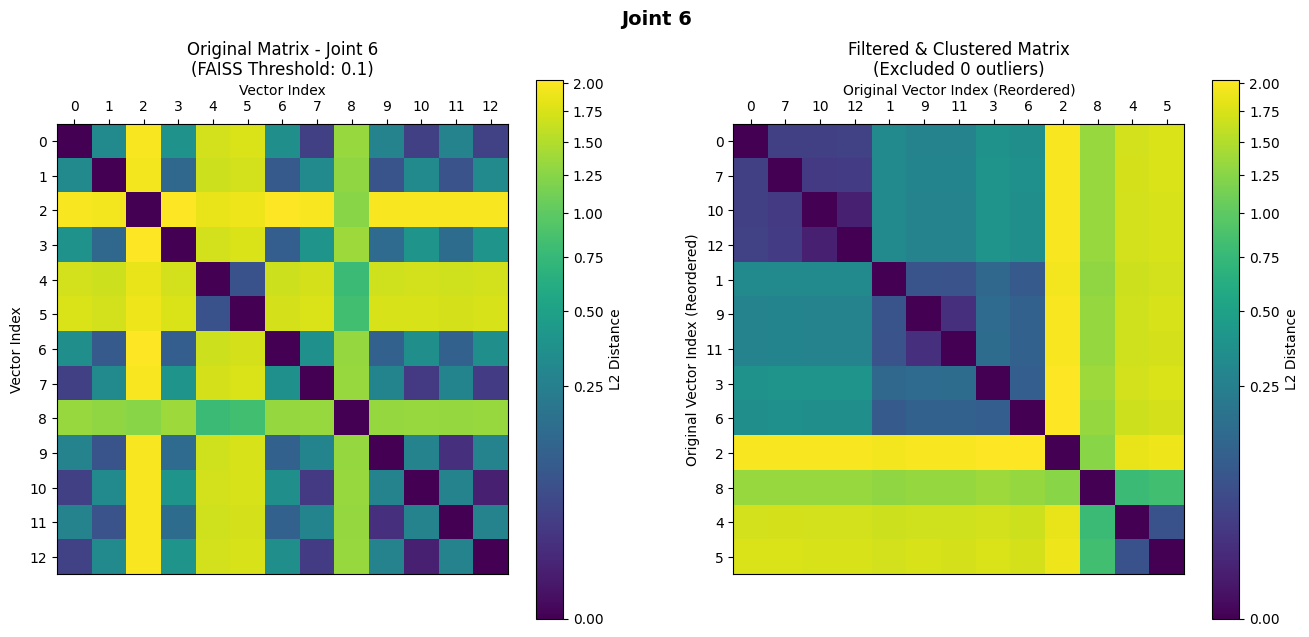

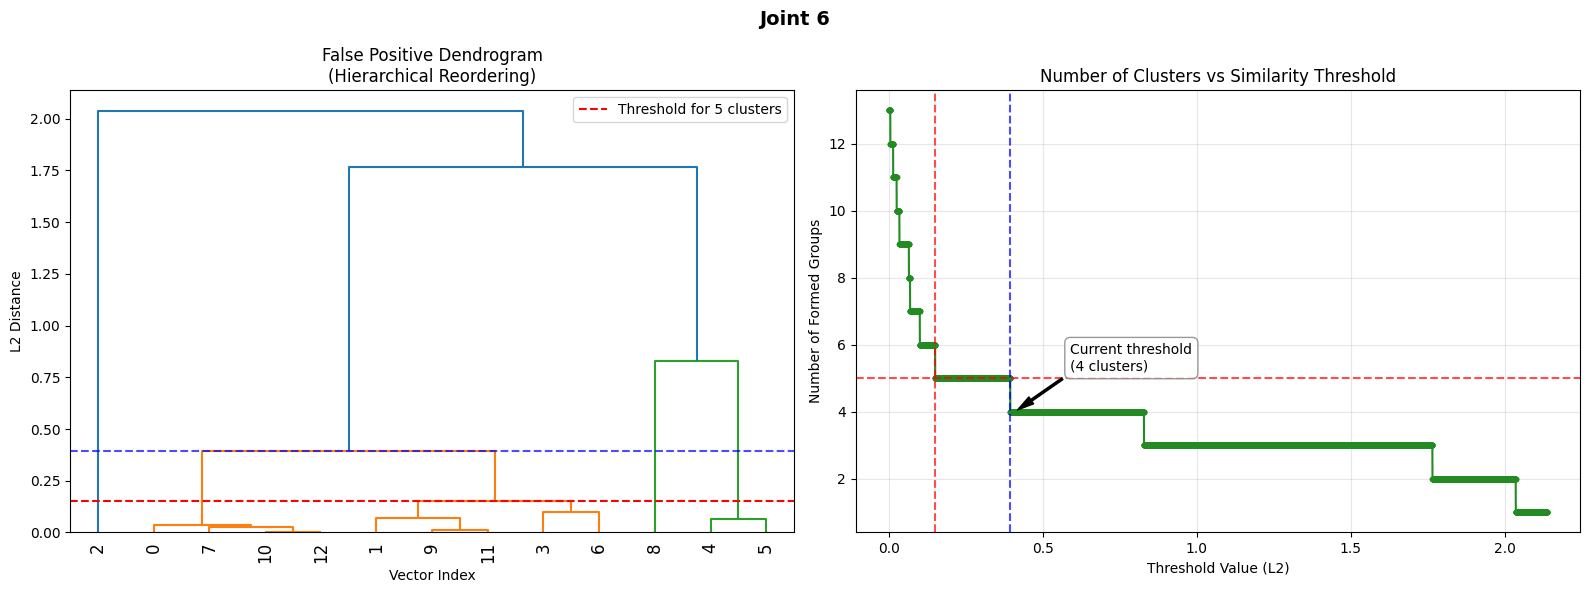


TECHNICAL ADVICE:
- If the number of clusters drops sharply (elbow), that's your ideal threshold.
- With threshold 0.409, your false positives are divided into 4 groups.

  THRESHOLD SUMMARY - ALL JOINTS
Joint    t_target_min       t_target_max      
--------------------------------------------
1        0.314162           0.707508          
2        0.303671           2.743411          
3        0.238649           0.497539          
4        0.336395           1.560992          
5        0.539264           4.364169          
6        0.150324           0.394092          

  GLOBAL ANALYSIS - TOTAL CLUSTERS ACROSS ALL JOINTS
With current threshold (0.409): 27 total clusters over 6 joints.


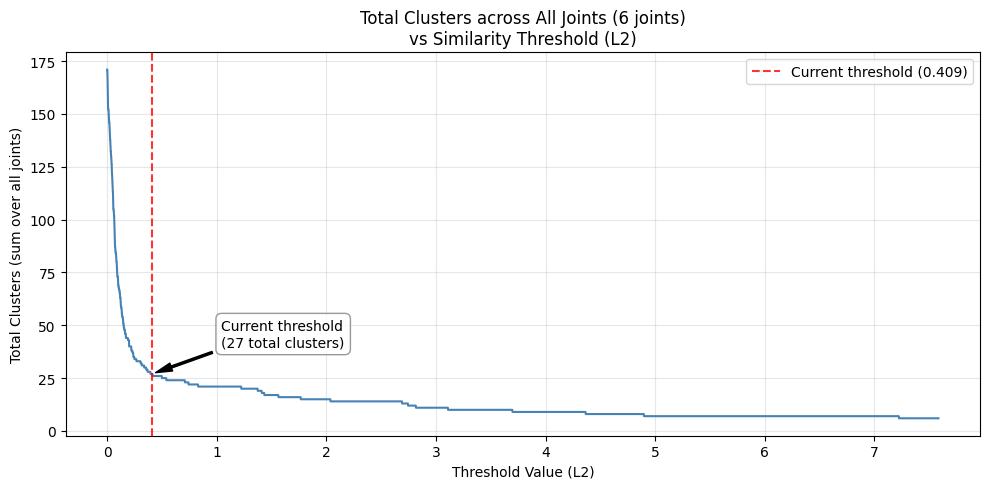


  GLOBAL CLUSTER TRANSITIONS
Total Clusters       t_min                t_max               
------------------------------------------------------------
171                  0.000000             0.000758            
170                  0.001517             0.001517            
168                  0.002275             0.002275            
167                  0.003034             0.003034            
164                  0.003792             0.003792            
163                  0.004551             0.004551            
160                  0.005309             0.005309            
157                  0.006068             0.006068            
155                  0.006826             0.006826            
153                  0.007585             0.008343            
152                  0.009101             0.012135            
151                  0.012894             0.012894            
149                  0.013652             0.013652            
148                  0.0144

In [1]:
import faiss
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from matplotlib.colors import PowerNorm

# =============================================================================
# --- CONFIGURATION: define here all per-joint parameters ---
# =============================================================================

n_joints = 6
FAISS_SIMILARITY_THRESHOLD = 0.409

#prima 0.167

# Base path: use {j} as placeholder for the joint number (1-indexed)
path_template = "C:\\Users\\Carlo\\time-series-autoencoder\\examples\\reconstruction\\faiss\\raw_index_joint{j}.index"

# Desired number of clusters per joint
n_cluster_per_joint = {
    1: 7,
    2: 2,
    3: 7,
    4: 2,
    5: 3,
    6: 5,
}

# Number of outliers to exclude per joint (0 = none)
n_outliers_per_joint = {
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0,
    6: 0,
}

# =============================================================================
# --- MAIN FUNCTION ---
# =============================================================================
current_t = FAISS_SIMILARITY_THRESHOLD

def analizza_joint(joint_id, path_index, n_cluster, n_outliers_vettori):
    """
    Analyzes a single FAISS joint.
    Returns (t_target_min, t_target_max) or (None, None) if not available.
    """
    print(f"\n{'='*60}")
    print(f"  JOINT {joint_id}")
    print(f"{'='*60}")

    # 1. Load index
    index = faiss.read_index(path_index)
    print(f"Embedding dimension: {index.d}")

    # 2. Verify and reconstruct
    n_total = index.ntotal
    print(f"Total vectors in the index: {n_total}")

    t_target_min = None
    t_target_max = None

    if n_total == 0:
        print("Index is empty.")
        return t_target_min, t_target_max, None, None

    vettori = index.reconstruct_n(0, n_total)
    dist_matrix = np.sqrt(np.sum((vettori[:, np.newaxis, :] - vettori[np.newaxis, :, :]) ** 2, axis=-1))
    mask = ~np.eye(n_total, dtype=bool)

    if n_total <= 1:
        print("Less than 2 vectors: cannot proceed.")
        return t_target_min, t_target_max, None, None

    dist_media_per_vettore = np.sum(dist_matrix, axis=1) / (n_total - 1)

    if n_outliers_vettori > 0:
        soglia_outlier = np.sort(dist_media_per_vettore)[-n_outliers_vettori]
        vettori_ok = dist_media_per_vettore < soglia_outlier
    else:
        vettori_ok = np.ones(n_total, dtype=bool)

    indici_mantenuti = np.where(vettori_ok)[0]

    print(f"Excluded vectors (outliers): {np.where(~vettori_ok)[0].tolist()}")
    print(f"Vectors used for statistics: {indici_mantenuti.tolist()}")

    dist_filtrata = dist_matrix[np.ix_(vettori_ok, vettori_ok)]
    mask_filtrata = ~np.eye(dist_filtrata.shape[0], dtype=bool)
    distanze_filtrate = dist_filtrata[mask_filtrata]
    distanze_reali = dist_matrix[mask]

    print(f"\n--- L2 Distance Statistics ---")
    print(f"Absolute minimum (all):          {distanze_reali.min():.6f}")
    print(f"Original mean (all):             {distanze_reali.mean():.6f}")
    print(f"Original median (all):           {np.median(distanze_reali):.6f}")
    print(f"Absolute maximum (all):          {distanze_reali.max():.6f}")
    print(f"---------------------------------------")

    if len(distanze_filtrate) > 0:
        print(f"Filtered minimum (without outliers): {distanze_filtrate.min():.6f}")
        print(f"Filtered mean (without outliers):  {distanze_filtrate.mean():.6f}")
        print(f"Filtered median (without outliers):{np.median(distanze_filtrate):.6f}")
        print(f"Filtered maximum (without outliers):  {distanze_filtrate.max():.6f}")

    if len(indici_mantenuti) <= 1:
        print("\nNot enough vectors (minimum 2 required).")
        return t_target_min, t_target_max, None, None

    # --- Hierarchical clustering for reordering ---
    dist_filtrata_sym = (dist_filtrata + dist_filtrata.T) / 2.0
    np.fill_diagonal(dist_filtrata_sym, 0)
    condensed_dist = squareform(dist_filtrata_sym)
    linkage_matrix = sch.linkage(condensed_dist, method='ward')
    nuovo_ordine = sch.leaves_list(linkage_matrix)
    dist_filtrata_ordinata = dist_filtrata[np.ix_(nuovo_ordine, nuovo_ordine)]
    etichette_ordinate = indici_mantenuti[nuovo_ordine]

    # --- Plot 1 & 2: Matrices ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"Joint {joint_id}", fontsize=14, fontweight='bold')

    im1 = ax1.imshow(dist_matrix, cmap='viridis', norm=PowerNorm(gamma=0.4))
    plt.colorbar(im1, ax=ax1, label='L2 Distance')
    ax1.set_title(f"Original Matrix - Joint {joint_id}\n(FAISS Threshold: 0.1)", pad=35)
    ax1.xaxis.tick_top()
    ax1.xaxis.set_label_position('top')
    ax1.set_xlabel("Vector Index")
    ax1.set_ylabel("Vector Index")

    im2 = ax2.imshow(dist_filtrata_ordinata, cmap='viridis', norm=PowerNorm(gamma=0.4))
    plt.colorbar(im2, ax=ax2, label='L2 Distance')
    ax2.set_title(f"Filtered & Clustered Matrix\n(Excluded {n_outliers_vettori} outliers)", pad=35)
    ax2.xaxis.tick_top()
    ax2.xaxis.set_label_position('top')
    ax2.set_xlabel("Original Vector Index (Reordered)")
    ax2.set_ylabel("Original Vector Index (Reordered)")

    if n_total <= 20:
        ax1.set_xticks(range(n_total))
        ax1.set_yticks(range(n_total))
        ax2.set_xticks(range(len(etichette_ordinate)))
        ax2.set_yticks(range(len(etichette_ordinate)))
        ax2.set_xticklabels(etichette_ordinate)
        ax2.set_yticklabels(etichette_ordinate)

    # --- Clustering Analysis for Threshold Setting ---
    print(f"\n--- Clustering Analysis for Threshold Setting ---")
    Z = sch.linkage(condensed_dist, method='complete')

    max_dist = distanze_filtrate.max()
    thresholds = np.linspace(0, max_dist * 1.05, 10000)
    n_clusters = []
    for t in thresholds:
        clusters = sch.fcluster(Z, t, criterion='distance')
        n_clusters.append(len(np.unique(clusters)))

    if n_cluster in n_clusters:
        indice_min = n_clusters.index(n_cluster)
        t_target_min = thresholds[indice_min]
        indice_max = len(n_clusters) - 1 - n_clusters[::-1].index(n_cluster)
        t_target_max = thresholds[indice_max]
        t_target = t_target_min
    else:
        t_target_min = t_target_max = t_target = 0.0001

    print(f"\n--- THRESHOLD SEARCH RESULT ---")
    if n_cluster in n_clusters:
        print(f"To obtain {n_cluster} clusters, the L2 distance must be between:")
        print(f"- MINIMUM:  {t_target_min:.6f}")
        print(f"- MAXIMUM: {t_target_max:.6f}")
    else:
        print(f"No exact cut found for {n_cluster} clusters. Using safe value.")

    # --- Plot 3 & 4: Dendrogram + Elbow ---
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))
    fig2.suptitle(f"Joint {joint_id}", fontsize=14, fontweight='bold')

    sch.dendrogram(Z, ax=ax3, leaf_rotation=90)
    ax3.axhline(y=t_target, color='r', linestyle='--', label=f'Threshold for {n_cluster} clusters')
    ax3.axhline(y=t_target_max, color='b', linestyle='--', alpha=0.7)
    ax3.set_title("False Positive Dendrogram\n(Hierarchical Reordering)")
    ax3.set_xlabel("Vector Index")
    ax3.set_ylabel("L2 Distance")
    ax3.legend()

    ax4.plot(thresholds, n_clusters, marker='o', markersize=3, color='forestgreen')
    ax4.axhline(y=n_cluster, color='r', linestyle='--', alpha=0.7)
    ax4.axvline(x=t_target, color='r', linestyle='--', alpha=0.7)
    ax4.axvline(x=t_target_max, color='b', linestyle='--', alpha=0.7)
    ax4.set_title("Number of Clusters vs Similarity Threshold")
    ax4.set_xlabel("Threshold Value (L2)")
    ax4.set_ylabel("Number of Formed Groups")
    ax4.grid(True, alpha=0.3)

    current_clusters = len(np.unique(sch.fcluster(Z, current_t, criterion='distance')))
    ax4.annotate(f'Current threshold\n({current_clusters} clusters)',
                 xy=(current_t, current_clusters),
                 xytext=(40, 30),
                 textcoords='offset points',
                 bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6))
    plt.tight_layout()
    plt.show()

    print(f"\nTECHNICAL ADVICE:")
    print(f"- If the number of clusters drops sharply (elbow), that's your ideal threshold.")
    print(f"- With threshold {current_t}, your false positives are divided into {current_clusters} groups.")

    return t_target_min, t_target_max, Z, distanze_filtrate

# =============================================================================
# --- LOOP OVER JOINTS ---
# =============================================================================

# Dictionary to collect results from all joints (for cross-analysis)
risultati = {}   # { joint_id: {"t_min": ..., "t_max": ...} }

for j in range(1, n_joints + 1):
    path = path_template.format(j=j)
    n_cluster = n_cluster_per_joint[j]
    n_outliers = n_outliers_per_joint[j]

    t_min, t_max, Z_j, dist_j = analizza_joint(
        joint_id=j,
        path_index=path,
        n_cluster=n_cluster,
        n_outliers_vettori=n_outliers,
    )

    risultati[j] = {"t_min": t_min, "t_max": t_max, "Z": Z_j, "dist": dist_j}

# =============================================================================
# --- FINAL SUMMARY (ready for cross-analysis) ---
# =============================================================================

print(f"\n{'='*60}")
print("  THRESHOLD SUMMARY - ALL JOINTS")
print(f"{'='*60}")
print(f"{'Joint':<8} {'t_target_min':<18} {'t_target_max':<18}")
print("-" * 44)
for j, res in risultati.items():
    t_min_str = f"{res['t_min']:.6f}" if res['t_min'] is not None else "N/A"
    t_max_str = f"{res['t_max']:.6f}" if res['t_max'] is not None else "N/A"
    print(f"{j:<8} {t_min_str:<18} {t_max_str:<18}")

# 'risultati' is available for any subsequent cross-analysis.
# Example access:
#   risultati[1]["t_min"]  →  t_target_min of joint 1
#   risultati[2]["t_max"]  →  t_target_max of joint 2

# =============================================================================
# --- GLOBAL ANALYSIS: total clusters across all joints for a common threshold ---
# =============================================================================

print(f"\n{'='*60}")
print("  GLOBAL ANALYSIS - TOTAL CLUSTERS ACROSS ALL JOINTS")
print(f"{'='*60}")

# Collect only joints with valid data
joint_validi = {j: res for j, res in risultati.items() if res["Z"] is not None and res["dist"] is not None}

if len(joint_validi) >= 2:
    # Threshold range: from global minimum to maximum across all joints
    global_max = max(res["dist"].max() for res in joint_validi.values())
    thresholds_global = np.linspace(0, global_max * 1.05, 10000)

    # For each threshold, sum the clusters of all joints
    n_clusters_totali = []
    for t in thresholds_global:
        tot = 0
        for res in joint_validi.values():
            clusters = sch.fcluster(res["Z"], t if t > 0 else 1e-10, criterion='distance')
            tot += len(np.unique(clusters))
        n_clusters_totali.append(tot)

    # Current threshold (same used in single plots)
    current_tot = 0
    for res in joint_validi.values():
        clusters = sch.fcluster(res["Z"], current_t, criterion='distance')
        current_tot += len(np.unique(clusters))

    print(f"With current threshold ({current_t}): {current_tot} total clusters over {len(joint_validi)} joints.")

    # --- Global elbow plot ---
    fig_global, ax_global = plt.subplots(figsize=(10, 5))
    ax_global.plot(thresholds_global, n_clusters_totali, color='steelblue', lw=1.5)
    ax_global.axvline(x=current_t, color='r', linestyle='--', alpha=0.8, label=f'Current threshold ({current_t})')
    ax_global.annotate(
        f'Current threshold\n({current_tot} total clusters)',
        xy=(current_t, current_tot),
        xytext=(50, 20),
        textcoords='offset points',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6)
    )
    ax_global.set_title(f"Total Clusters across All Joints ({len(joint_validi)} joints)\nvs Similarity Threshold (L2)")
    ax_global.set_xlabel("Threshold Value (L2)")
    ax_global.set_ylabel("Total Clusters (sum over all joints)")
    ax_global.grid(True, alpha=0.3)
    ax_global.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Not enough joints with valid data for global analysis.")

print(f"\n{'='*60}")
print("  GLOBAL CLUSTER TRANSITIONS")
print(f"{'='*60}")
print(f"{'Total Clusters':<20} {'t_min':<20} {'t_max':<20}")
print("-" * 60)

n_clusters_arr_int = np.array(n_clusters_totali, dtype=int)
valori_unici = np.unique(n_clusters_arr_int)[::-1]  # from highest to lowest

for val in valori_unici:
    indici = np.where(n_clusters_arr_int == val)[0]
    t_min_val = thresholds_global[indici[0]]
    t_max_val = thresholds_global[indici[-1]]
    print(f"{val:<20} {t_min_val:<20.6f} {t_max_val:<20.6f}")